In [1]:
import pandas as pd
import numpy as np
import pymcdm
import matplotlib.pyplot as plt
import seaborn as sns

RANCOM

In [2]:
def f_three_value(c1, c2):
    if c1 < c2:
        return 1
    if c1 == c2:
        return 0.5
    return 0

def RANCOM(ranking, f = f_three_value, tie_value = 0.5, verbose=False):
    """Calculate criteria weights based on the given numerical hierarchy. Lower value means higher relevance.

    Parameters
    ----------
        ranking : ndarray
            Numerical values for criteria relevance (lower - more relevant).
        
        f : callable
            Objective function used for filling the Matrix of ranking Comparison (MAC).

        tie_value: float
            Value used to fill MAC when tie is noted

    Returns
    -------
        ndarray
            Criteria weights in range 0-1.
    """

    def build_mac(ranking):
        co = np.array(list(ranking))

        mac = np.diag(np.ones(co.shape[0]) * tie_value)
        for i in range(mac.shape[0]):
            for j in range(i+1, mac.shape[1]):
                v = f(co[i], co[j])
                mac[i, j] = v
                if tie_value == 1:
                    mac[j,i] = 1 / v
                else:
                    mac[j, i] = 1 - v
        return mac

    def get_weights(ranking):
        mac = build_mac(ranking)
        scw = np.sum(mac, axis=1)
        p = scw / np.sum(scw)
        

        if verbose:
            print('------- MAC ---------')
            print(mac)
            print('------- SCW ---------')
            print(scw)
            print('------- WEIGHTS ---------')
            print(p)

        return p, mac

    return get_weights(ranking)
    

https://www.kaggle.com/datasets/amirmotefaker/supply-chain-dataset

In [3]:
alpha = 0.88    # Sensitivity to gains
beta = 0.88     # Sensitivity to losses
lambda_ = 2.25  # Loss aversion parameter

def prospect_value(x, alpha=0.88, beta=0.88, loss_aversion=2.25):
    """
    Prospect Theory value function

    alpha : curvature for gains (0 < alpha <= 1)
    beta  : curvature for losses (0 < beta <= 1)
    loss_aversion : lambda > 1
    """
    return np.where(
        x >= 0,
        x ** alpha,
        -loss_aversion * ((-x) ** beta)
    )


def prospect_theory_value_vis(x, neutral_value, criteria_type, alpha=alpha, lambda_=lambda_):
    x_diff = x - neutral_value
    if criteria_type == -1:
        x_diff = - x_diff

    values = np.where(x_diff >= 0, x_diff ** alpha, -lambda_ * (-x_diff) ** alpha)  

    return values 

def prospect_theory_value_matrix(value, neutral_value, criteria_type, alpha=alpha, beta=beta, lambda_=lambda_):
    diff = value - neutral_value

    if criteria_type == 1:
        if diff > 0:    
            return (value - neutral_value)**alpha
        return -lambda_ * (-(value - neutral_value)) ** beta
    
    if diff < 0:    
        return (-(value - neutral_value))**alpha
    return -lambda_ * ((value - neutral_value)) ** beta

def max_abs_normalization(x):
    return x / np.max(np.abs(x), axis=0)

In [4]:
def ridm(
    matrix, 
    neutral_values, 
    criteria_types, 
    weights, 
    alpha_: float = 0.88,
    beta_: float = 0.88,
    lambda_: float = 2.25, 
    verbose: bool = False,
    normalization: callable = max_abs_normalization
):
    if normalization and normalization not in [max_abs_normalization]:
        nmatrix = normalization(matrix)
        np_matrix = np.vstack([matrix, neutral_values])
        n_neutral_values = normalization(np_matrix)[-1, :]
    else: 
        nmatrix= matrix.copy()
        n_neutral_values = neutral_values.copy()

    result_matrix = np.zeros_like(nmatrix).astype(float)
    result_matrix_neg = np.zeros_like(nmatrix).astype(float)


    for i in range(nmatrix.shape[1]):    
        for k in range(nmatrix.shape[0]):
            result_matrix_neg[k, i] = prospect_theory_value_matrix(
                nmatrix[k, i], 
                n_neutral_values[i], 
                criteria_types[i],
                alpha=alpha_,
                beta=beta_,
                lambda_=lambda_
            )

    if verbose:
        print(np.round(result_matrix_neg, 3))

    if normalization and normalization in [max_abs_normalization]:
        result_matrix_neg = normalization(result_matrix_neg)
    wmatrix = weights * result_matrix_neg

    ri = np.sum(wmatrix, axis=1)
    rank = pymcdm.helpers.rrankdata(ri)

    if verbose:
        print(np.round(result_matrix_neg, 3))
        print(np.round(wmatrix, 3))
        print(ri)
        print(rank)

    return ri, rank


In [5]:
data_df = pd.read_csv('supply_chain_data.csv')
data_df

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864


In [6]:
criteria_set = [
    'Shipping costs', # -1
    'Manufacturing costs', # -1
    'Costs', # -1,
    'Revenue generated', # 1
    'Number of products sold', # 1
    'Availability', # 1
]


In [7]:
product_type = 'skincare'
products_df = data_df[data_df['Product type'] == product_type][criteria_set]
print(products_df.shape)
products_df

(40, 6)


,Shipping costs,Manufacturing costs,Costs,Revenue generated,Number of products sold,Availability
1,9.716575,33.616769,503.065579,7460.900065,736,95
3,1.729569,35.624741,254.776159,7766.836426,83,68
4,3.890548,92.065161,923.440632,2686.505152,871,26
6,3.880763,1.085069,134.369097,7823.476560,65,48
9,7.166645,47.957602,995.929461,4971.145988,980,35
10,8.673211,96.527353,806.103178,2330.965802,996,11
11,4.523943,27.592363,126.723033,6099.944116,960,95
13,9.537283,97.829050,547.241005,4052.738416,249,5
14,2.039770,5.791437,929.235290,8653.570926,562,26
15,2.422040,97.121282,127.861800,5442.086785,469,94


In [8]:
matrix = products_df.to_numpy()
criteria_types = np.array([-1, -1, -1, 1, 1, 1])
criteria_performance_rank = np.array([6, 5, 4, 3, 2, 1])
rancom_w, mac = RANCOM(criteria_performance_rank)
rancom_w

array([0.02777778, 0.08333333, 0.13888889, 0.19444444, 0.25      ,
       0.30555556])

In [9]:
marcos = pymcdm.methods.MARCOS()
prefs = marcos(matrix, rancom_w, criteria_types)
ranks = marcos.rank(prefs)

for i in range(len(prefs)):
    print(f'A{i+1}: {prefs[i]} {ranks[i]}')

A1: 0.6588423868921157 5.0
A2: 0.46226215921312536 19.0
A3: 0.37557254929342754 29.0
A4: 0.5232285155408484 15.0
A5: 0.4724639399607744 17.0
A6: 0.352422484493135 33.0
A7: 0.7815984516436096 1.0
A8: 0.19056302326691144 39.0
A9: 0.43903645406494657 22.0
A10: 0.6445456514917557 8.0
A11: 0.4502653263331542 20.0
A12: 0.44140035698654806 21.0
A13: 0.34551441287777895 34.0
A14: 0.35797858061455595 31.0
A15: 0.5455745396863431 14.0
A16: 0.6903828295360434 2.0
A17: 0.5493539231581012 13.0
A18: 0.40889530558476267 27.0
A19: 0.1999329187841979 38.0
A20: 0.677166384666067 4.0
A21: 0.4175765631259667 26.0
A22: 0.40267090352774454 28.0
A23: 0.6868409028573431 3.0
A24: 0.43581104174059054 23.0
A25: 0.5578755657229014 11.0
A26: 0.43403707228849414 24.0
A27: 0.6566052995245446 6.0
A28: 0.3645040526537612 30.0
A29: 0.35246368906389014 32.0
A30: 0.2729822952307396 35.0
A31: 0.5892043629480229 9.0
A32: 0.5557875347381965 12.0
A33: 0.4731049929498405 16.0
A34: 0.42925795642914244 25.0
A35: 0.1833861961785

RIDM

In [10]:
print(np.min(matrix, axis=0))
print(np.max(matrix, axis=0))

[1.01348657e+00 1.08506857e+00 1.10364335e+02 1.22959103e+03
 6.50000000e+01 1.00000000e+00]
[   9.71657477   97.82905011  995.9294615  9655.13510272  996.
  100.        ]


In [11]:
neutral_points = np.array([6, 35, 300, 5000, 500, 60])
risk_scores, risk_rank = ridm(matrix, neutral_points, criteria_types, rancom_w)
for i in range(len(prefs)):
    print(f'A{i+1}: {risk_scores[i]} {risk_rank[i]}')

A1: 0.1365388504897765 4.0
A2: -0.13357484552274348 15.0
A3: -0.4131863458106461 32.0
A4: -0.21172259683685934 21.0
A5: -0.19470993076030255 20.0
A6: -0.48578157509953446 35.0
A7: 0.2609915927996115 1.0
A8: -0.6647970211496788 39.0
A9: -0.17923179232122335 17.0
A10: 0.019742580602915477 9.0
A11: -0.22931452286866674 22.0
A12: -0.3254954431407748 29.0
A13: -0.36079239060191515 30.0
A14: -0.3656452896618897 31.0
A15: -0.022254738388933562 13.0
A16: 0.19473120095433338 2.0
A17: 8.484494981797486e-05 11.0
A18: -0.2803000933592701 26.0
A19: -0.6017645321133345 37.0
A20: 0.0861421063220393 5.0
A21: -0.18619763195751976 18.0
A22: -0.44563083848668555 33.0
A23: 0.16349070535726878 3.0
A24: -0.19139529923045498 19.0
A25: -0.14590545574295355 16.0
A26: -0.25873556284905475 24.0
A27: -0.02080018185948994 12.0
A28: -0.3248556571395227 28.0
A29: -0.29773402788257886 27.0
A30: -0.470190927861412 34.0
A31: 0.037031825669990144 8.0
A32: 0.05916307721624531 7.0
A33: -0.12219256353280247 14.0
A34: -0.23

In [15]:
print(len([r for r in risk_scores if r >=0 ]))
print(len([r for r in risk_scores if r < 0 ]))

11
29


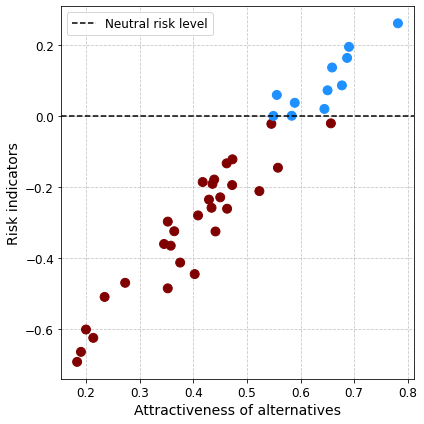

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['axes.axisbelow'] = True
plt.figure(figsize=(6, 6))

colors = ['maroon' if r < 0 else 'dodgerblue' for r in risk_scores]

plt.scatter(prefs, risk_scores, color=colors, s=80)
plt.axhline(y=0, color='black', linestyle='--', label='Neutral risk level')

plt.ylabel("Risk indicators", fontsize=14)
plt.xlabel("Attractiveness of alternatives", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(axis='both', alpha=0.7, linestyle='--')
plt.legend(loc='upper left', ncol=2, fontsize=12)

plt.tight_layout()
plt.savefig('scatter_v2.png', dpi=300)
plt.show()

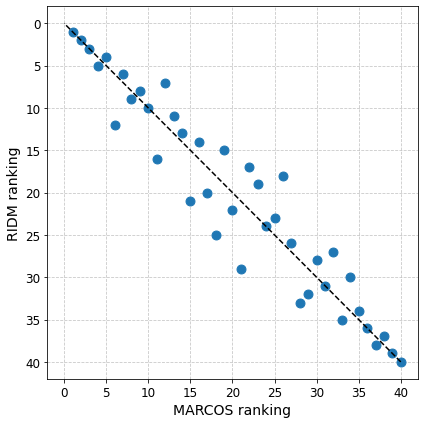

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['axes.axisbelow'] = True
plt.figure(figsize=(6, 6))

# Scatter plot wszystkich punktów
plt.scatter(ranks, len(ranks) - risk_rank, s=80)
plt.plot(np.arange(len(ranks), -1, -5), np.arange(0, len(ranks)+1, 5), linestyle='--', color='k')


# Etykiety osi
plt.ylabel("RIDM ranking", fontsize=14)
plt.xlabel("MARCOS ranking", fontsize=14)
plt.xticks(np.arange(0, len(ranks)+1, 5), fontsize=12)
plt.yticks(np.arange(0, len(ranks)+1, 5), np.arange(len(ranks), -1, -5), fontsize=12)

# Siatka
plt.grid(axis='both', alpha=0.7, linestyle='--')

plt.tight_layout()
plt.savefig('ranking.png', dpi=300)
plt.show()

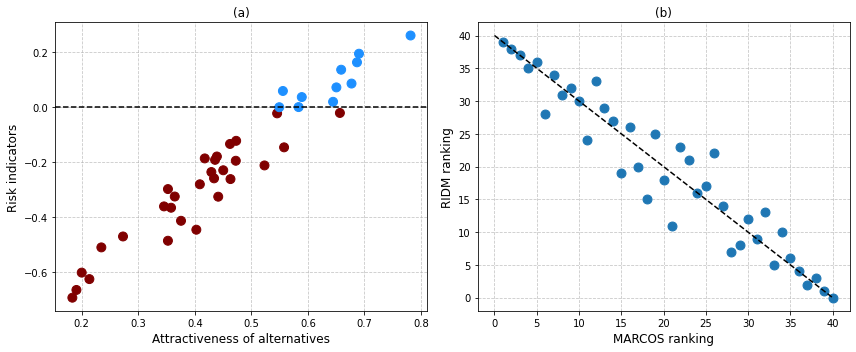

In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['maroon' if r < 0 else 'dodgerblue' for r in risk_scores]

axes[0].scatter(prefs, risk_scores, color=colors, s=80)
axes[0].axhline(y=0, color='black', linestyle='--')

axes[0].set_xlabel("Attractiveness of alternatives", fontsize=12)
axes[0].set_ylabel("Risk indicators", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].set_title('(a)', fontsize=12)

axes[1].scatter(ranks, len(ranks) - risk_rank, s=80)
axes[1].plot(
    np.arange(0, len(ranks)+1, 5),
    np.arange(len(ranks), -1, -5),
    linestyle='--',
    color='black'
)

axes[1].set_xlabel("MARCOS ranking", fontsize=12)
axes[1].set_ylabel("RIDM ranking", fontsize=12)

axes[1].set_xticks(np.arange(0, len(ranks)+1, 5))
axes[1].set_yticks(np.arange(0, len(ranks)+1, 5))

axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].set_title('(b)', fontsize=12)

plt.tight_layout()
plt.savefig('combined_plot.png', dpi=300)
plt.show()

Different behavioral approaches

In [31]:
points_params = [
    np.array([3, 25, 300, 4000, 450, 80]),
    np.array([6, 60, 700, 8000, 800, 85]),
    np.array([4, 30, 400, 4500, 550, 95])
]

top_n = 5

for params in points_params:
    ri, rank = ridm(matrix, params, criteria_types, rancom_w,
                    alpha_=0.88, beta_=0.88, lambda_=2.25)
    
    top_indices = np.argsort(-ri)[:top_n]
    
    print(f"\nScenario: {params}")
    print("Top 5 alternatives (indices):", top_indices)
    print("RIDM scores:", np.round(ri[top_indices], 3))
    print('Number of alts above neutral risk: ', len(ri[ri>0]))


Scenario: [   3   25  300 4000  450   80]
Top 5 alternatives (indices): [ 6 15 22  0 19]
RIDM scores: [0.248 0.194 0.169 0.135 0.083]
Number of alts above neutral risk:  11

Scenario: [   6   60  700 8000  800   85]
Top 5 alternatives (indices): [ 6 15 22  0 19]
RIDM scores: [ 0.135  0.065  0.049  0.013 -0.062]
Number of alts above neutral risk:  4

Scenario: [   4   30  400 4500  550   95]
Top 5 alternatives (indices): [ 6 15 22  0 19]
RIDM scores: [0.172 0.122 0.079 0.063 0.005]
Number of alts above neutral risk:  5


11
4
5


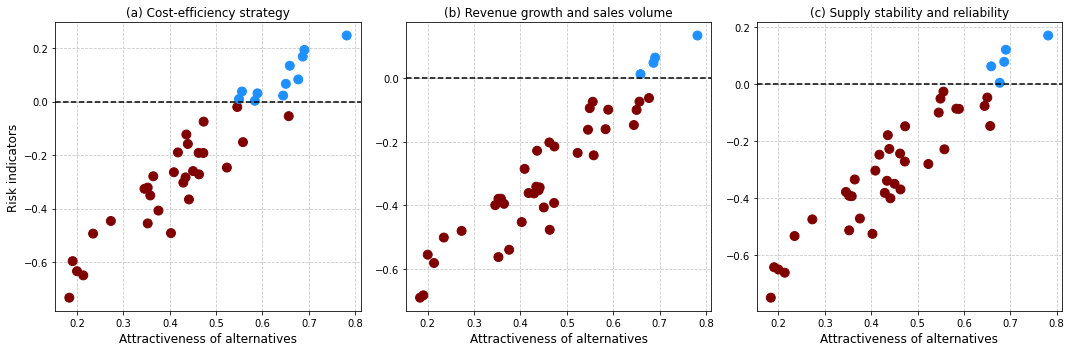

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# scenariusze
points_params = [
    np.array([3, 25, 300, 4000, 450, 80]),
    np.array([6, 60, 700, 8000, 800, 85]),
    np.array([4, 30, 400, 4500, 550, 95])
]

scenario_titles = [
    'Cost-efficiency strategy',
    'Revenue growth and sales volume',
    'Supply stability and reliability'
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, params in enumerate(points_params):

    ri, rank = ridm(
        matrix,
        params,
        criteria_types,
        rancom_w,
        alpha_=0.88,
        beta_=0.88,
        lambda_=2.25
    )

    colors = ['maroon' if r < 0 else 'dodgerblue' for r in ri]
    print(len([r for r in ri if r > 0]))

    axes[i].scatter(prefs, ri, color=colors, s=80)

    axes[i].axhline(y=0, color='black', linestyle='--')

    axes[i].set_xlabel("Attractiveness of alternatives", fontsize=12)

    if i == 0:
        axes[i].set_ylabel("Risk indicators", fontsize=12)

    axes[i].grid(True, linestyle='--', alpha=0.7)

    axes[i].set_title(f'({chr(97+i)}) {scenario_titles[i]}', fontsize=12)

plt.tight_layout()
plt.savefig('sensitivity_scores.png', dpi=300)
plt.show()

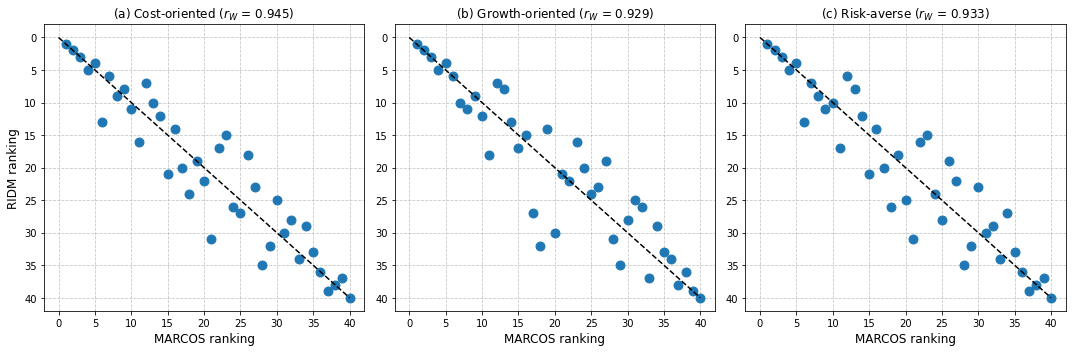

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# scenariusze
points_params = [
    np.array([3, 25, 300, 4000, 450, 80]),
    np.array([6, 60, 700, 8000, 800, 85]),
    np.array([4, 30, 400, 4500, 550, 95])
]

scenario_titles = [
    'Cost-oriented',
    'Growth-oriented',
    'Risk-averse'
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, params in enumerate(points_params):

    ri, rank = ridm(
        matrix,
        params,
        criteria_types,
        rancom_w,
        alpha_=0.88,
        beta_=0.88,
        lambda_=2.25
    )

    rw = np.round(pymcdm.correlations.rw(ranks, rank), 3)
    axes[i].scatter(ranks, len(ranks) - rank, s=80)
    axes[i].plot(
        np.arange(0, len(ranks)+1, 5),
        np.arange(len(ranks), -1, -5),
        linestyle='--',
        color='black'
    )

    axes[i].set_xlabel("MARCOS ranking", fontsize=12)

    if i == 0:
        axes[i].set_ylabel("RIDM ranking", fontsize=12)

    axes[i].set_xticks(np.arange(0, len(ranks)+1, 5))
    axes[i].set_yticks(np.arange(0, len(ranks)+1, 5))
    axes[i].set_yticklabels(np.arange(len(ranks), -1, -5))

    axes[i].grid(True, linestyle='--', alpha=0.7)

    axes[i].set_title(f'({chr(97+i)}) {scenario_titles[i]} ($r_W$ = {rw})', fontsize=12)

plt.tight_layout()
plt.savefig('sensitivity_rankings.png', dpi=300)
plt.show()